# Monte Carlo Multi-Asset Portfolio Risk Simulator

## Project Overview

This project develops an interactive Monte Carlo simulation framework for analysing the risk and return characteristics of multi-asset portfolios.

The model uses historical market data across US equities, European equities, US Treasuries and gold to estimate asset returns, volatility and cross-asset relationships. Cholesky decomposition is used to generate correlated return scenarios across the portfolio.

The framework allows users to adjust portfolio allocations, investment horizon, number of simulations and market conditions, and evaluates portfolio outcomes using:

- Expected annual return
- Annualised volatility
- Sharpe ratio
- Probability of loss
- Value at Risk (VaR)
- Expected Shortfall (ES)
- Simulated terminal portfolio values

The model also compares Growth, Balanced and Defensive portfolio allocations and incorporates a hypothetical stressed-market scenario.

> **Purpose:** The model is designed as a portfolio risk and scenario-analysis framework rather than a forecasting tool.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import ipywidgets as widgets

from IPython.display import display, clear_output

print("Monte Carlo Portfolio Model")

Monte Carlo Portfolio Model


## 1. Asset Universe & Historical Data

The portfolio uses five liquid ETFs representing different asset classes and geographic exposures:

- **SPY** – US large-cap equities (S&P 500)
- **QQQ** – US technology/growth equities (Nasdaq-100)
- **IEUR** – European equities
- **TLT** – Long-duration US Treasury bonds
- **GLD** – Gold

Combining equity, fixed-income and alternative exposures allows the model to examine the effects of diversification and cross-asset correlation on portfolio risk.

In [2]:
tickers = ["SPY", "QQQ", "IEUR", "TLT", "GLD"]

prices = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices = prices[tickers]

returns = np.log(prices / prices.shift(1)).dropna()

print("Historical data loaded successfully.")
print(f"Observations: {len(returns):,}")
print(f"Assets: {', '.join(tickers)}")

prices.tail()

[*********************100%***********************]  5 of 5 completed

Historical data loaded successfully.
Observations: 1,254
Assets: SPY, QQQ, IEUR, TLT, GLD


Ticker,SPY,QQQ,IEUR,TLT,GLD
Date,,,,,
2025-12-24,685.029480,621.812256,69.616173,85.405457,411.929993
2025-12-26,684.959961,621.772400,69.821938,85.124084,416.739990
2025-12-29,682.519043,618.762634,69.547585,85.444260,398.600006
2025-12-30,681.685547,617.327515,69.812134,85.240524,398.890015
2025-12-31,676.635010,612.224915,69.547585,84.561386,396.309998


## 2. Monte Carlo Methodology

Historical daily log returns are used to estimate the mean return vector and covariance matrix of the five assets.

Because asset returns are correlated, independently generated random shocks would fail to preserve the estimated relationships between assets. Cholesky decomposition of the covariance matrix is therefore used to transform independent random variables into correlated shocks.

For each simulation, these correlated returns are used to generate a potential portfolio path over the selected investment horizon.

The resulting distribution of portfolio outcomes is then analysed using both conventional volatility measures and downside-risk measures such as VaR and Expected Shortfall.

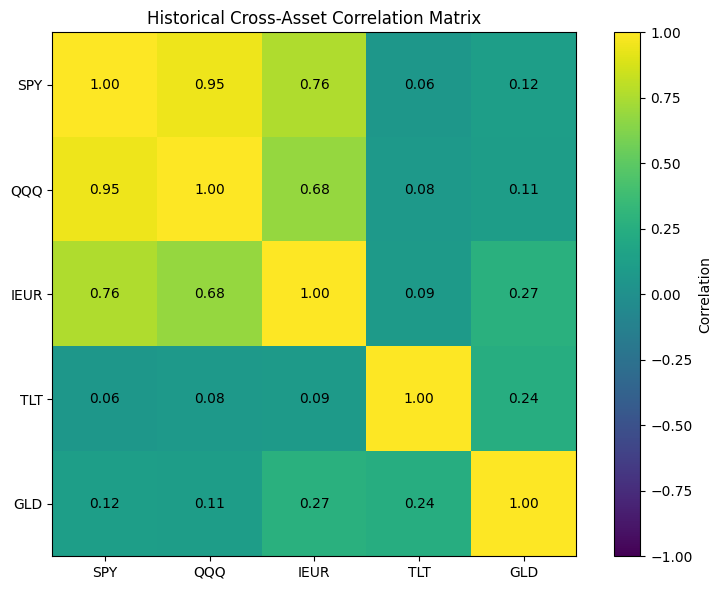

In [3]:
correlation_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))

ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(heatmap, label="Correlation")
plt.title("Historical Cross-Asset Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Interactive Portfolio Simulator

The interactive simulator allows the user to modify the initial investment, investment horizon, number of Monte Carlo simulations, market scenario and portfolio allocation.

Users can select between predefined Growth, Balanced and Defensive strategies or construct a custom portfolio by adjusting individual asset weights.

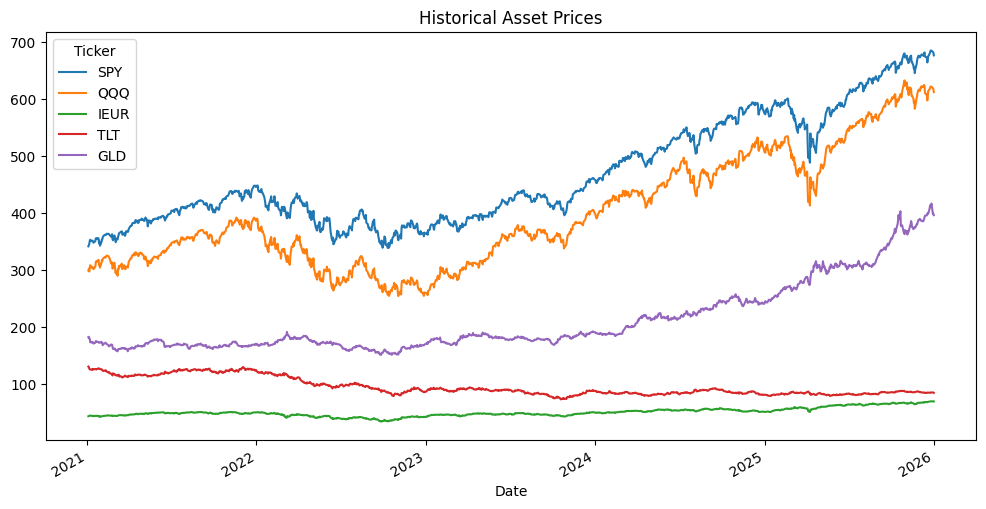

In [4]:
prices.plot(figsize=(12,6))
plt.title("Historical Asset Prices")
plt.show()

In [5]:

# ---------------------------------------------------------
# INTERACTIVE CONTROLS
# ---------------------------------------------------------

investment_widget = widgets.IntText(
    value=100000,
    description='Investment €:',
    style={'description_width': '120px'}
)

years_widget = widgets.Dropdown(
    options=[1, 2, 3, 5, 10],
    value=1,
    description='Years:',
    style={'description_width': '120px'}
)

simulations_widget = widgets.Dropdown(
    options=[1000, 5000, 10000, 50000],
    value=10000,
    description='Simulations:',
    style={'description_width': '120px'}
)

scenario_widget = widgets.Dropdown(
    options=['Normal', 'Stressed'],
    value='Normal',
    description='Scenario:',
    style={'description_width': '120px'}
)

# Portfolio weight sliders
spy_widget = widgets.IntSlider(
    value=30, min=0, max=100, step=5,
    description='S&P 500:',
    style={'description_width': '120px'}
)

qqq_widget = widgets.IntSlider(
    value=20, min=0, max=100, step=5,
    description='NASDAQ:',
    style={'description_width': '120px'}
)

ieur_widget = widgets.IntSlider(
    value=20, min=0, max=100, step=5,
    description='Europe:',
    style={'description_width': '120px'}
)

tlt_widget = widgets.IntSlider(
    value=15, min=0, max=100, step=5,
    description='Treasuries:',
    style={'description_width': '120px'}
)

gld_widget = widgets.IntSlider(
    value=15, min=0, max=100, step=5,
    description='Gold:',
    style={'description_width': '120px'}
)

portfolio_widget = widgets.Dropdown(
    options=["Custom", "Growth", "Balanced", "Defensive"],
    value="Custom",
    description="Portfolio:",
    style={"description_width": "120px"}
)
run_button = widgets.Button(
    description='Run Simulation',
    button_style='success'
)

output = widgets.Output()

In [6]:
def update_portfolio(change):

    selected = change["new"]

    if selected == "Growth":

        spy_widget.value = 40
        qqq_widget.value = 30
        ieur_widget.value = 15
        tlt_widget.value = 5
        gld_widget.value = 10

    elif selected == "Balanced":

        spy_widget.value = 30
        qqq_widget.value = 15
        ieur_widget.value = 20
        tlt_widget.value = 20
        gld_widget.value = 15

    elif selected == "Defensive":

        spy_widget.value = 20
        qqq_widget.value = 5
        ieur_widget.value = 15
        tlt_widget.value = 40
        gld_widget.value = 20


portfolio_widget.observe(
    update_portfolio,
    names="value"
)

### Simulation Engine

The simulation engine generates correlated daily asset returns using the historical covariance structure of the five assets.

Cholesky decomposition is used to transform independently generated random shocks into correlated shocks, allowing the simulations to reflect historical cross-asset relationships.

For each simulated path, portfolio returns are calculated over the selected investment horizon and used to generate a distribution of potential ending portfolio values.

The **Stressed** scenario is a hypothetical sensitivity test in which volatility is increased by 50% and expected daily log returns are reduced by 0.05 percentage points. These assumptions are deliberately imposed and should not be interpreted as a forecast of a specific market crisis.

In [7]:
def run_interactive_simulation(button):

    with output:

        clear_output(wait=True)

        # --------------------------------
        # Read user inputs
        # --------------------------------

        initial_investment = investment_widget.value
        years = years_widget.value
        num_simulations = simulations_widget.value
        scenario = scenario_widget.value

        weights = np.array([
            spy_widget.value,
            qqq_widget.value,
            ieur_widget.value,
            tlt_widget.value,
            gld_widget.value
        ]) / 100

        # --------------------------------
        # Check portfolio weights
        # --------------------------------

        if not np.isclose(weights.sum(), 1.0):

            print(
                f"⚠️ Portfolio weights currently total "
                f"{weights.sum() * 100:.0f}%."
            )

            print("Please make sure they total 100%.")
            return

        # --------------------------------
        # Historical parameters
        # --------------------------------

        mean_daily = returns.mean().values
        cov_daily = returns.cov().values

        # --------------------------------
        # Stress scenario
        # --------------------------------

        if scenario == "Stressed":

            # Increase volatility by 50%
            cov_daily = cov_daily * (1.5 ** 2)

            # Reduce expected daily returns
            mean_daily = mean_daily - 0.0005

        # --------------------------------
        # Cholesky decomposition
        # --------------------------------

        L = np.linalg.cholesky(cov_daily)

        num_days = int(252 * years)

        simulation_results = np.zeros(num_simulations)

        paths_to_plot = []
        number_paths = 100

        # --------------------------------
        # Monte Carlo Simulation
        # --------------------------------

        for simulation in range(num_simulations):

            random_shocks = np.random.normal(
                size=(num_days, len(weights))
            )

            correlated_shocks = random_shocks @ L.T

            simulated_returns = (
                mean_daily + correlated_shocks
            )

            portfolio_daily_returns = (
                simulated_returns @ weights
            )

            cumulative_returns = np.exp(
                np.cumsum(portfolio_daily_returns)
            )

            portfolio_path = (
                initial_investment * cumulative_returns
            )

            simulation_results[simulation] = (
                portfolio_path[-1]
            )

            if simulation < number_paths:
                paths_to_plot.append(portfolio_path)

        # --------------------------------
        # Risk statistics
        # --------------------------------

        mean_value = np.mean(simulation_results)

        median_value = np.median(simulation_results)

        percentile_5 = np.percentile(
            simulation_results, 5
        )

        percentile_95 = np.percentile(
            simulation_results, 95
        )

        probability_loss = np.mean(
            simulation_results < initial_investment
        )

        var_95 = max(
            0,
            initial_investment - percentile_5
        )

        tail_losses = simulation_results[
            simulation_results <= percentile_5
        ]

        expected_shortfall = max(
            0,
            initial_investment - np.mean(tail_losses)
        )

        expected_return = (
            mean_value / initial_investment
        ) ** (1 / years) - 1

        # --------------------------------
        # Volatility and Sharpe Ratio
        # --------------------------------

        risk_free_rate = 0.03

        annual_cov = cov_daily * 252

        portfolio_volatility = np.sqrt(
            weights.T @ annual_cov @ weights
        )

        sharpe_ratio = (
            expected_return - risk_free_rate
        ) / portfolio_volatility

        # --------------------------------
        # Results table
        # --------------------------------

        results = pd.DataFrame({

            "Metric": [
                "Initial Investment",
                "Mean Ending Value",
                "Median Ending Value",
                "Expected Annual Return",
                "Annualised Volatility",
                "Sharpe Ratio",
                "Probability of Loss",
                "5th Percentile",
                "95th Percentile",
                "95% VaR",
                "95% Expected Shortfall"
            ],

            "Result": [
                f"€{initial_investment:,.0f}",
                f"€{mean_value:,.0f}",
                f"€{median_value:,.0f}",
                f"{expected_return:.2%}",
                f"{portfolio_volatility:.2%}",
                f"{sharpe_ratio:.2f}",
                f"{probability_loss:.2%}",
                f"€{percentile_5:,.0f}",
                f"€{percentile_95:,.0f}",
                f"€{var_95:,.0f}",
                f"€{expected_shortfall:,.0f}"
            ]
        })

        # --------------------------------
        # Display results
        # --------------------------------

        print("\nMONTE CARLO PORTFOLIO RISK ANALYSIS")
        print("-----------------------------------")

        print(f"Scenario: {scenario}")
        print(f"Time Horizon: {years} year(s)")
        print(f"Simulations: {num_simulations:,}")
        print(f"Risk-Free Rate: {risk_free_rate:.1%}")

        display(results)

        # --------------------------------
        # Distribution Histogram
        # --------------------------------

        plt.figure(figsize=(11, 6))

        plt.hist(
            simulation_results,
            bins=75
        )

        plt.axvline(
            initial_investment,
            linestyle="--",
            label="Initial Investment"
        )

        plt.axvline(
            median_value,
            linestyle="--",
            label="Median Outcome"
        )

        plt.axvline(
            percentile_5,
            linestyle="--",
            label="5th Percentile"
        )

        plt.axvline(
            percentile_95,
            linestyle="--",
            label="95th Percentile"
        )

        plt.title(
            f"{years}-Year Monte Carlo Portfolio Distribution"
        )

        plt.xlabel("Ending Portfolio Value (€)")
        plt.ylabel("Frequency")

        plt.legend()
        plt.show()

        # --------------------------------
        # Simulated Portfolio Paths
        # --------------------------------

        plt.figure(figsize=(11, 6))

        for path in paths_to_plot:
            plt.plot(path, alpha=0.15)

        plt.axhline(
            initial_investment,
            linestyle="--",
            label="Initial Investment"
        )

        plt.title(
            f"100 Simulated Portfolio Paths – "
            f"{scenario} Scenario"
        )

        plt.xlabel("Trading Days")
        plt.ylabel("Portfolio Value (€)")

        plt.legend()
        plt.show()


# Connect button to simulation
run_button.on_click(run_interactive_simulation)

In [8]:
print("MONTE CARLO PORTFOLIO SIMULATOR")
print("")

display(
    investment_widget,
    years_widget,
    simulations_widget,
    scenario_widget,
    portfolio_widget
)

print("\nPORTFOLIO ALLOCATION")

display(
    spy_widget,
    qqq_widget,
    ieur_widget,
    tlt_widget,
    gld_widget
)

display(run_button)

display(output)

MONTE CARLO PORTFOLIO SIMULATOR



IntText(value=100000, description='Investment €:', style=DescriptionStyle(description_width='120px'))

Dropdown(description='Years:', options=(1, 2, 3, 5, 10), style=DescriptionStyle(description_width='120px'), va…

Dropdown(description='Simulations:', index=2, options=(1000, 5000, 10000, 50000), style=DescriptionStyle(descr…

Dropdown(description='Scenario:', options=('Normal', 'Stressed'), style=DescriptionStyle(description_width='12…

...

IntSlider(value=20, description='Europe:', step=5, style=SliderStyle(description_width='120px'))

IntSlider(value=15, description='Treasuries:', step=5, style=SliderStyle(description_width='120px'))

IntSlider(value=15, description='Gold:', step=5, style=SliderStyle(description_width='120px'))

Button(button_style='success', description='Run Simulation', style=ButtonStyle())

Output()

## 4. Strategic Asset Allocation Comparison

To examine how asset allocation affects portfolio risk and return, the model compares three predefined investment strategies:

- **Growth Portfolio** – Higher allocation to US equities and growth assets, with lower fixed-income exposure.
- **Balanced Portfolio** – More evenly distributed exposure across equities, US Treasuries and gold.
- **Defensive Portfolio** – Higher allocation to US Treasuries and gold, with reduced equity exposure.

All three portfolios are evaluated using the **same simulated market scenarios**. This allows differences in their results to be driven by asset allocation rather than different random draws.

The portfolios are compared using expected return, annualised volatility, Sharpe ratio, probability of loss, Value at Risk (VaR) and Expected Shortfall.

In [9]:
# =========================================================
# PORTFOLIO COMPARISON
# Growth vs Balanced vs Defensive
# =========================================================

portfolios = {

    "Growth": np.array([
        0.40,  # S&P 500
        0.30,  # NASDAQ
        0.15,  # Europe
        0.05,  # Treasuries
        0.10   # Gold
    ]),

    "Balanced": np.array([
        0.30,  # S&P 500
        0.15,  # NASDAQ
        0.20,  # Europe
        0.20,  # Treasuries
        0.15   # Gold
    ]),

    "Defensive": np.array([
        0.20,  # S&P 500
        0.05,  # NASDAQ
        0.15,  # Europe
        0.40,  # Treasuries
        0.20   # Gold
    ])
}

print("Portfolio strategies created successfully.")

for name, weights in portfolios.items():
    print(f"{name}: {weights.sum():.0%} allocated")

Portfolio strategies created successfully.
Growth: 100% allocated
Balanced: 100% allocated
Defensive: 100% allocated


In [10]:
def compare_portfolios():

    # --------------------------------
    # Settings
    # --------------------------------

    initial_investment = investment_widget.value
    years = years_widget.value
    num_simulations = simulations_widget.value
    scenario = scenario_widget.value

    risk_free_rate = 0.03

    # --------------------------------
    # Historical data
    # --------------------------------

    mean_daily = returns.mean().values
    cov_daily = returns.cov().values

    # --------------------------------
    # Apply stress scenario
    # --------------------------------

    if scenario == "Stressed":

        cov_daily = cov_daily * (1.5 ** 2)

        mean_daily = mean_daily - 0.0005

    annual_cov = cov_daily * 252

    num_days = int(252 * years)

    # --------------------------------
    # Cholesky decomposition
    # --------------------------------

    L = np.linalg.cholesky(cov_daily)

    # --------------------------------
    # Generate SAME market scenarios
    # for all portfolios
    # --------------------------------

    random_shocks = np.random.normal(
        size=(
            num_simulations,
            num_days,
            len(tickers)
        )
    )

    correlated_shocks = (
        random_shocks @ L.T
    )

    simulated_asset_returns = (
        mean_daily + correlated_shocks
    )

    # --------------------------------
    # Store results
    # --------------------------------

    comparison_results = []

    # --------------------------------
    # Test each portfolio
    # --------------------------------

    for name, weights in portfolios.items():

        portfolio_daily_returns = (
            simulated_asset_returns @ weights
        )

        ending_values = (
            initial_investment *
            np.exp(
                np.sum(
                    portfolio_daily_returns,
                    axis=1
                )
            )
        )

        # Mean ending value

        mean_value = np.mean(
            ending_values
        )

        # Expected annual return

        expected_return = (
            mean_value / initial_investment
        ) ** (1 / years) - 1

        # Annualised volatility

        volatility = np.sqrt(
            weights.T @
            annual_cov @
            weights
        )

        # Sharpe Ratio

        sharpe_ratio = (
            expected_return -
            risk_free_rate
        ) / volatility

        # Probability of losing money

        probability_loss = np.mean(
            ending_values <
            initial_investment
        )

        # 5th percentile

        percentile_5 = np.percentile(
            ending_values,
            5
        )

        # Value at Risk

        var_95 = max(
            0,
            initial_investment -
            percentile_5
        )

        # Expected Shortfall

        tail_losses = ending_values[
            ending_values <= percentile_5
        ]

        expected_shortfall = max(
            0,
            initial_investment -
            np.mean(tail_losses)
        )

        # Store results

        comparison_results.append({

            "Portfolio":
                name,

            "Expected Return":
                expected_return,

            "Volatility":
                volatility,

            "Sharpe Ratio":
                sharpe_ratio,

            "Probability of Loss":
                probability_loss,

            "95% VaR":
                var_95,

            "Expected Shortfall":
                expected_shortfall,

            "Mean Ending Value":
                mean_value
        })

    comparison = pd.DataFrame(
        comparison_results
    )

    return comparison

In [11]:
comparison = compare_portfolios()

display(
    comparison.style.format({

        "Expected Return":
            "{:.2%}",

        "Volatility":
            "{:.2%}",

        "Sharpe Ratio":
            "{:.2f}",

        "Probability of Loss":
            "{:.2%}",

        "95% VaR":
            "€{:,.0f}",

        "Expected Shortfall":
            "€{:,.0f}",

        "Mean Ending Value":
            "€{:,.0f}"
    })
)

,Portfolio,Expected Return,Volatility,Sharpe Ratio,Probability of Loss,95% VaR,Expected Shortfall,Mean Ending Value
0,Growth,14.48%,15.85%,0.72,22.19%,"€12,466","€18,143","€114,479"
1,Balanced,9.99%,12.66%,0.55,24.27%,"€11,168","€15,906","€109,992"
2,Defensive,5.26%,10.96%,0.21,33.81%,"€12,795","€16,666","€105,261"


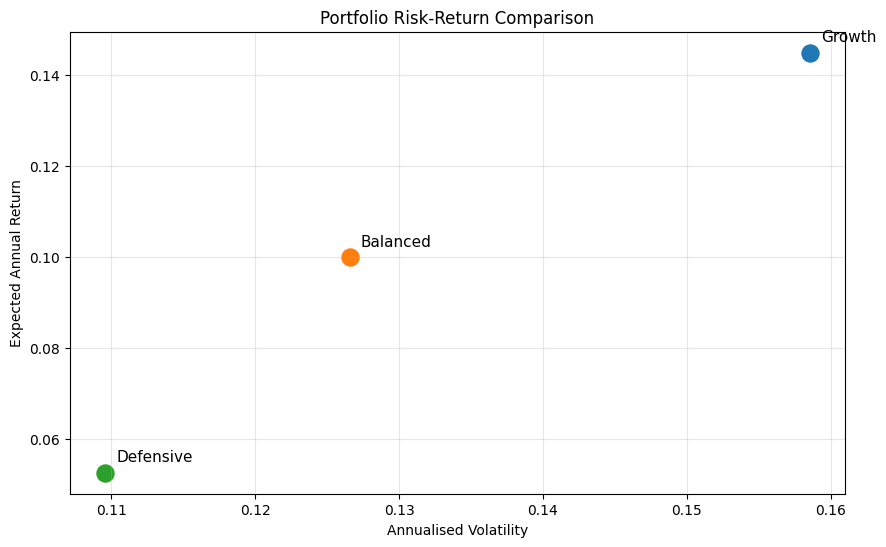

In [12]:
plt.figure(figsize=(10, 6))

for _, row in comparison.iterrows():

    plt.scatter(
        row["Volatility"],
        row["Expected Return"],
        s=150
    )

    plt.annotate(
        row["Portfolio"],
        (
            row["Volatility"],
            row["Expected Return"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )

plt.xlabel(
    "Annualised Volatility"
)

plt.ylabel(
    "Expected Annual Return"
)

plt.title(
    "Portfolio Risk-Return Comparison"
)

plt.grid(alpha=0.3)

plt.show()

## 5. Model Assumptions & Limitations

This model is designed as a portfolio risk and scenario-analysis framework rather than a prediction of future market performance.

Key limitations include:

1. **Historical parameter estimation** – Expected returns, volatility and covariance are estimated from historical observations and may not represent future market conditions.

2. **Distributional assumptions** – Simulated shocks do not fully capture characteristics of real financial markets such as fat tails, volatility clustering and extreme market discontinuities.

3. **Changing correlations** – Cross-asset correlations are estimated historically but can change significantly, particularly during periods of market stress.

4. **Expected-return uncertainty** – Historical sample mean returns are noisy estimates of forward-looking expected returns.

5. **Portfolio construction assumptions** – The simulation simplifies the mechanics of portfolio rebalancing and transaction costs.

6. **Stress testing** – The stressed scenario represents a hypothetical sensitivity analysis rather than a forecast of a specific financial crisis.

Despite these limitations, the framework demonstrates how Monte Carlo simulation can be used to analyse portfolio outcome distributions, diversification, downside risk and the effects of strategic asset allocation.